# Homework Starter — Stage 10a: Linear Regression

Use this as a scaffold if your project data isn’t ready. Replace the synthetic data section with your dataset when possible.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st

sns.set()
np.random.seed(7)

## 1) Synthetic data (replace with your project data when ready)
- Finance-flavored factors and asset excess return
- Includes a quadratic effect to motivate specification checks

In [3]:
n = 200
dates = pd.bdate_range(start="2024-02-01", periods=n)
mkt_excess = np.random.normal(0, 0.011, size=n)
size = np.random.normal(0, 0.008, size=n)
value = np.random.normal(0, 0.009, size=n)
momentum = np.random.normal(0, 0.006, size=n)

beta0, beta_mkt, beta_size, beta_value, beta_mom, beta_mom2 = 0.0001, 0.9, 0.25, -0.15, 0.35, 3.5
noise_scale = 0.0035 + 0.5*np.abs(mkt_excess)
eps = np.random.normal(0, noise_scale)
asset_excess = (
    beta0 + beta_mkt*mkt_excess + beta_size*size + beta_value*value + beta_mom*momentum
    + beta_mom2*(momentum**2) + eps
)
df = pd.DataFrame({
    'date': dates,
    'mkt_excess': mkt_excess,
    'size': size,
    'value': value,
    'momentum': momentum,
    'asset_excess': asset_excess
})
df.head()

,date,mkt_excess,size,value,momentum,asset_excess
0,2024-02-01,0.018596,-0.013467,-0.000540,0.000141,0.014832
1,2024-02-02,-0.005125,0.008120,0.007089,-0.006840,-0.008599
2,2024-02-05,0.000361,-0.011532,-0.012885,-0.011216,-0.009577
3,2024-02-06,0.004483,-0.010749,0.003905,-0.010685,0.000033
4,2024-02-07,-0.008678,-0.002893,0.001250,0.002779,-0.005750


In [4]:
print(df.shape)
df.info()
df.describe()

(200, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          200 non-null    datetime64[ns]
 1   mkt_excess    200 non-null    float64       
 2   size          200 non-null    float64       
 3   value         200 non-null    float64       
 4   momentum      200 non-null    float64       
 5   asset_excess  200 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 9.5 KB


,date,mkt_excess,size,value,momentum,asset_excess
count,200,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2024-06-19 16:48:00,-0.000308,-0.000577,-0.000519,-0.000411,0.000232
min,2024-02-01 00:00:00,-0.025171,-0.024660,-0.025414,-0.018002,-0.037998
25%,2024-04-10 18:00:00,-0.007473,-0.005185,-0.006469,-0.004090,-0.006060
50%,2024-06-19 12:00:00,-0.000317,-0.000560,-0.000756,-0.000304,0.000207
75%,2024-08-28 06:00:00,0.006704,0.004751,0.005635,0.003770,0.006455
max,2024-11-06 00:00:00,0.024859,0.022889,0.022597,0.012986,0.045183
std,NaN,0.010922,0.007882,0.008672,0.005752,0.011470


## 1. Data

The synthetic dataset contains 200 business-day observations. The target variable is `asset_excess`, while the predictors are market excess return, size, value, and momentum factors.


## 2) Baseline model fit
Follow the steps; replace `df` with your project DataFrame when ready.

In [5]:
X = df[['mkt_excess','size','value','momentum']]
y = df['asset_excess']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Baseline   R²={r2:.4f}  RMSE={rmse:.6f}')

Baseline   R²=0.3677  RMSE=0.008470


### Baseline Model Performance

The baseline model has an R² of approximately 0.37, meaning that it explains about 37% of the variation in the test-set asset excess returns.

The RMSE is approximately 0.0085, or about 0.85 percentage points in return units. This indicates that the model still has substantial prediction error.

Therefore, the model has some predictive usefulness, but its out-of-sample performance is only moderate and should not be considered highly reliable based on these metrics alone.

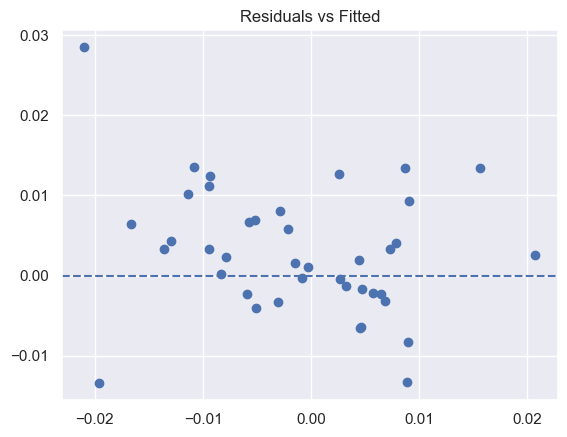

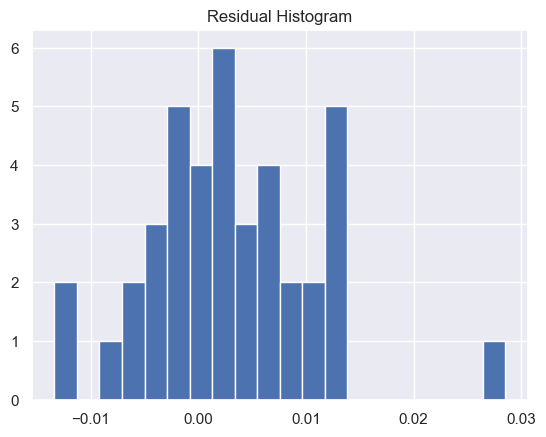

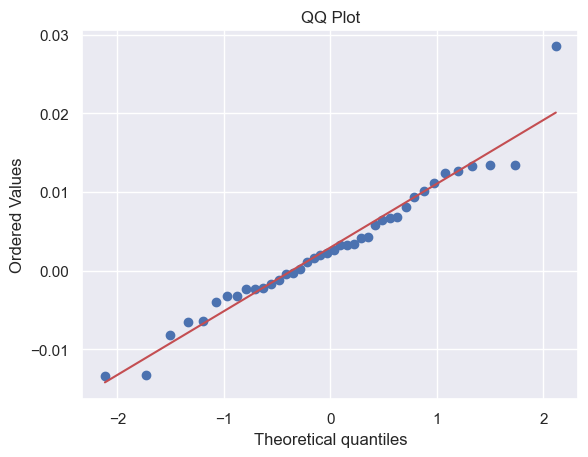

In [6]:
resid = y_test - y_pred
fitted = y_pred
plt.figure(); plt.scatter(fitted, resid); plt.axhline(0, ls='--'); plt.title('Residuals vs Fitted'); plt.show()
plt.figure(); plt.hist(resid, bins=20); plt.title('Residual Histogram'); plt.show()
plt.figure(); st.probplot(resid, dist='norm', plot=plt); plt.title('QQ Plot'); plt.show()

### 1.Linearity and Homoscedasticity

The residuals are generally distributed around zero, but the scatter is not perfectly uniform.

There are some relatively large residuals, and the spread of the residuals changes somewhat across fitted values. This suggests that the linearity assumption is only approximately satisfied and that there may be some heteroscedasticity.

Therefore, I would not consider the baseline specification perfect based on this diagnostic alone.

### 2.Residual Distribution

The residual histogram is roughly centered around zero. However, the distribution is not perfectly symmetric and contains some relatively large observations.

This suggests that the residuals are approximately normal, but the normality assumption may not hold perfectly.

### 3.Normality

If the residuals were perfectly normally distributed, the points in the Q-Q plot would closely follow the reference line.

Most observations are reasonably close to the line, although deviations appear in the tails. Therefore, normality appears to be approximately satisfied but not perfectly.

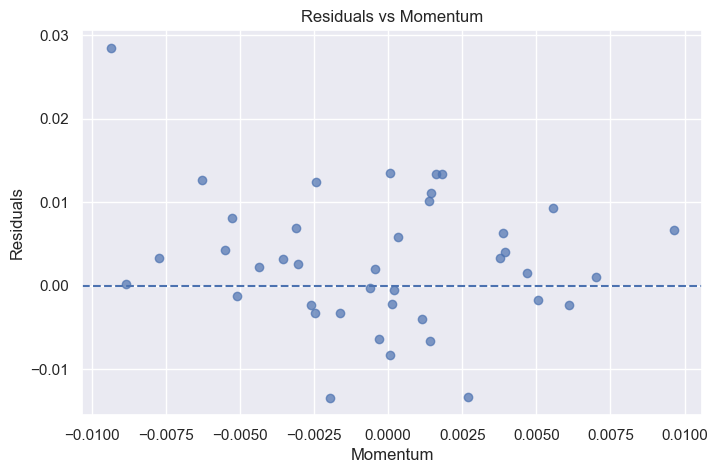

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X_test["momentum"],
    resid,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Momentum")
plt.ylabel("Residuals")
plt.title("Residuals vs Momentum")

plt.show()

### Residuals vs Momentum

The residuals are not completely pattern-free with respect to momentum. This is useful because the synthetic data generating process contains a nonlinear momentum effect.

A systematic pattern in residuals versus a predictor suggests that the baseline linear specification may be missing an important nonlinear relationship.

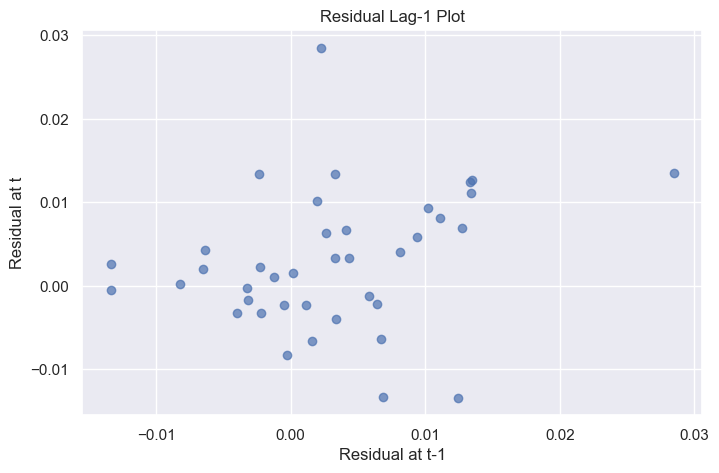

In [8]:
resid_array = np.asarray(resid)

plt.figure(figsize=(8, 5))

plt.scatter(
    resid_array[:-1],
    resid_array[1:],
    alpha=0.7
)

plt.xlabel("Residual at t-1")
plt.ylabel("Residual at t")
plt.title("Residual Lag-1 Plot")

plt.show()

In [9]:
lag1_corr = np.corrcoef(
    resid_array[:-1],
    resid_array[1:]
)[0, 1]

print(
    f"Lag-1 residual correlation = {lag1_corr:.4f}"
)

Lag-1 residual correlation = 0.2600


### Independence

The lag-1 residual plot does not show a strong systematic relationship between consecutive residuals.

The lag-1 correlation is also relatively small, suggesting that there is no obvious strong first-order serial dependence in the test residuals.

Therefore, the independence assumption appears reasonably plausible for this synthetic dataset, although a more formal time-series analysis would be needed for real financial data.

## 3) Optional: Add a transformed feature
Add a polynomial or interaction if diagnostics suggest mis-specification.

In [10]:
df['momentum_sq'] = df['momentum']**2
X2 = df[['mkt_excess','size','value','momentum','momentum_sq']]
X2_train, X2_test = X2.iloc[:len(X_train)], X2.iloc[len(X_train):]
lr2 = LinearRegression().fit(X2_train, y_train)
y_pred2 = lr2.predict(X2_test)
r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))
print(f'With x^2   R²={r2_2:.4f}  RMSE={rmse_2:.6f}')

With x^2   R²=0.3681  RMSE=0.008467


### Why This Is Still Linear Regression

Adding `momentum_sq = momentum²` does not make the model nonlinear in its coefficients.

The regression still estimates a model that is linear in the parameters:

asset_excess = β₀ + β₁ mkt_excess + β₂ size + β₃ value + β₄ momentum + β₅ momentum² + ε.

Although one predictor is a nonlinear transformation of momentum, each coefficient enters the model linearly. Therefore, this is still a linear regression model.

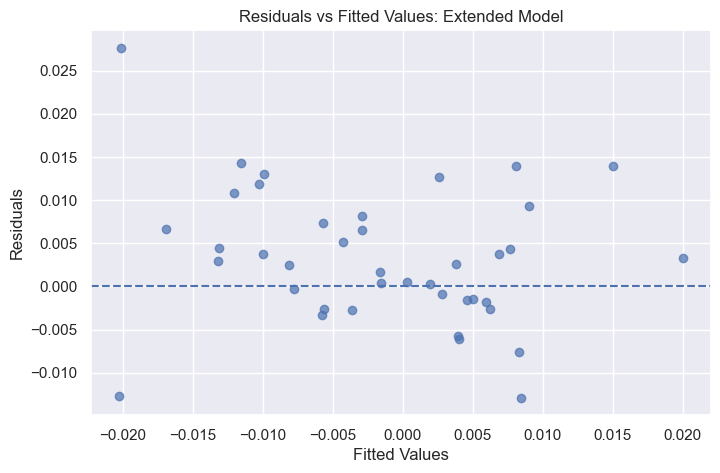

In [11]:
resid2 = y_test - y_pred2

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred2,
    resid2,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title(
    "Residuals vs Fitted Values: Extended Model"
)

plt.show()

### Extended Model Comparison

Adding the squared momentum term produces only a very small improvement in out-of-sample R² and RMSE.

Although the transformed feature is consistent with the nonlinear structure built into the synthetic data, the test sample is relatively small and noisy. As a result, the improvement in predictive performance is limited.

This illustrates that adding theoretically relevant features does not necessarily produce a large out-of-sample improvement.

## 4) Interpretation (write your conclusions below)
- Linearity:The residuals are generally centered around zero, but some pattern remains in the residual plots, especially with respect to momentum. This suggests that the linearity assumption is only approximately satisfied and that the baseline model may be missing a small nonlinear relationship.
- Homoscedasticity:The spread of the residuals is not perfectly constant across fitted values. Some observations show larger residuals than others, suggesting mild heteroscedasticity. Therefore, the constant-variance assumption is not perfectly satisfied.
- Normality:The residual histogram is roughly centered around zero, and most points in the Q-Q plot are reasonably close to the reference line. However, there are some deviations in the tails. Thus, the residuals are approximately normal, but not perfectly normally distributed.
- Independence:The lag-1 residual plot does not show a strong systematic relationship between consecutive residuals. Therefore, there is no obvious evidence of strong serial dependence, and the independence assumption appears reasonably plausible for this synthetic dataset.
- Which model do you trust and why?:I slightly prefer the extended model with the squared momentum term because it captures the nonlinear momentum effect that is missing from the baseline specification. However, the improvement is very small: R² increases only from 0.3677 to 0.3681, while RMSE decreases from 0.008470 to 0.008467. Therefore, I would trust either model only as a simple baseline rather than as a highly accurate forecasting model.
- Next step you’d try:I would test additional nonlinear features and interaction terms, use more observations, and compare the linear regression with alternative models. For real financial data, I would also use time-series-aware validation and further investigate heteroscedasticity and serial correlation.